
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Dependencies

In [1]:
# 1. IMPORT CÁC THƯ VIỆN CẦN THIẾT
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
# Thiết lập backend đồ họa mặc định
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
# Load Logger OOP từ file ngoài
include("../src/logger.jl")
logger = EvaluationLogger()


log_success(logger, "Dependencies loaded")


[success] Dependencies loaded


In [2]:
Random.seed!(42)
CONFIG = Dict(
    "dataset" => "../data/benchmark/chess.dat/chess.dat",
    "spmf_jar" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    
    "output_julia" => "../results/chess_julia.txt",
    "output_spmf" => "../results/chess_spmf.txt",
    
    "min_sups" => [0.9, 0.8, 0.7, 0.6],
    "csv_minsup" => "../results/chess_metrics_minsup.csv",
    
    "data_ratios" => [0.4, 0.6, 0.8, 1.0], 
    "fixed_minsup_for_scalability" => 0.7,
    "csv_scalability" => "../results/chess_metrics_scalability.csv"
)

if !isdir("../results") mkdir("../results") end
log_success(logger, "Config loaded")


[success] Config loaded


## Helpers

In [3]:
# Load Logger OOP từ file ngoài
include("../src/logger.jl")
logger = EvaluationLogger()

# Load các hàm Hỗ trợ Đánh giá
include("../src/eval_utils.jl")
log_success(logger, "Đã khởi tạo các hàm hỗ trợ thành công!")


[success] Helpers initialized


## Correctness Evaluation

In [4]:
function eval_correctness(config)
    log_phase(logger, "CORRECTNESS")
    log_info(logger, "Kiểm chứng độ chính xác ở ngưỡng MinSup=", config["fixed_minsup_for_scalability"] * 100, "%")
    
    transactions = FPGrowth.read_spmf(config["dataset"])
    total_txs = length(transactions)
    min_sup_abs = ceil(Int, config["fixed_minsup_for_scalability"] * total_txs)
    
    # 1. Chạy Julia
    log_process(logger, "Đang thực thi Julia FPGrowth...")
    julia_result = FPGrowth.fpgrowth(transactions, min_sup_abs)
    FPGrowth.write_spmf(config["output_julia"], julia_result)
    
    # 2. Chạy SPMF
    log_process(logger, "Đang thực thi SPMF Built-in...")
    exe_spmf(config, config["dataset"], config["output_spmf"], config["fixed_minsup_for_scalability"])
    
    # 3. So khớp
    log_info(logger, "Thực hiện so khớp kết quả...")
    my_res = parse_output(config["output_julia"])
    spmf_res = parse_output(config["output_spmf"])
    
    missing_in_mine = length(setdiff(spmf_res, my_res))
    missing_in_spmf = length(setdiff(my_res, spmf_res))
    
    return Dict(
        "Julia_Count" => length(my_res),
        "SPMF_Count" => length(spmf_res),
        "Missing_in_Julia" => missing_in_mine,
        "Missing_in_SPMF" => missing_in_spmf
    )
end

function vis_correctness(res::Dict)
    log_phase(logger, "Visualize")
    if res["Missing_in_Julia"] == 0 && res["Missing_in_SPMF"] == 0
        log_success(logger, "chính xác 100% (", res["Julia_Count"], " frequent itemsets)")
    else
        log_fail(logger, "không chính xác: Lệch Julia: ", res["Missing_in_Julia"], " | Lệch SPMF: ", res["Missing_in_SPMF"])
    end
    
    # Vẽ biểu đồ Cột
    categories = ["Julia From Scratch", "SPMF Built-in"]
    counts = [res["Julia_Count"], res["SPMF_Count"]]
    
    p = bar(categories, counts, 
            title="Correctness evaluation",
            ylabel="Itemsets", 
            legend=false, 
            color=[:blue, :green], 
            bar_width=0.4)
    display(plot(p, bottom_margin=5mm))
end


vis_correctness (generic function with 1 method)


__________________________________________________
[phase]  CORRECTNESS
__________________________________________________
[info] Kiểm chứng độ chính xác ở ngưỡng MinSup=70.0%
[process] Đang thực thi Julia FPGrowth...
[process] Đang thực thi SPMF Built-in...
[info] Thực hiện so khớp kết quả...

__________________________________________________
[phase]  Visualize
__________________________________________________
[success] chính xác 100% (48731 frequent itemsets)


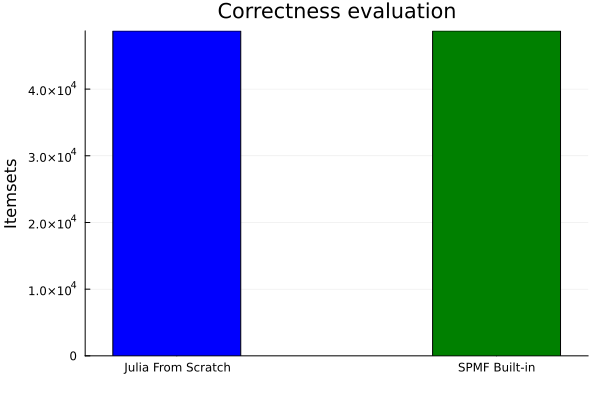

In [5]:
correctness_results = eval_correctness(CONFIG)
vis_correctness(correctness_results)


--- 
## Performance Evaluation

In [ ]:
function eval_performance(config)
    log_phase(logger, "PERFORMANCE")
    transactions = FPGrowth.read_spmf(config["dataset"])
    total_txs = length(transactions)
    log_info(logger, "Tổng số giao dịch: ", total_txs)
    
    results_df = DataFrame(MinSup=Float64[], JuliaTime=Float64[], JuliaMemMB=Float64[], SPMFTime=Float64[], SPMFMemMB=Float64[])

    @showprogress "Đang đo hiệu năng... " for min_sup_ratio in config["min_sups"]
        log_process(logger, "Đang thực thi với min_sup = ", min_sup_ratio * 100, "% ...")
        min_sup_abs = ceil(Int, min_sup_ratio * total_txs)
        
        # JIT Warmup
        if min_sup_ratio == config["min_sups"][1]
            FPGrowth.fpgrowth(transactions[1:min(100, end)], ceil(Int, min_sup_ratio * 100))
        end
        
        # Julia
        julia_mem_bytes = @allocated begin
            time_before = time_ns()
            FPGrowth.fpgrowth(transactions, min_sup_abs)
            time_after = time_ns()
        end
        julia_time = (time_after - time_before) / 1e9
        julia_mem_mb = julia_mem_bytes / (1024^2)
        
        # SPMF
        spmf_time, spmf_mem_mb = exe_spmf(config, config["dataset"], config["output_spmf"], min_sup_ratio)
        
        log_metric(logger, "Julia -> Time: ", round(julia_time, digits=3), "s | RAM: ", round(julia_mem_mb, digits=2), " MB")
        log_metric(logger, "SPMF  -> Time: ", round(spmf_time, digits=3), "s | RAM: ", round(spmf_mem_mb, digits=2), " MB")
        
        push!(results_df, (min_sup_ratio, julia_time, julia_mem_mb, spmf_time, spmf_mem_mb))
    end
    
    CSV.write(config["csv_minsup"], results_df)
    log_success(logger, "Saved at ", config["csv_minsup"])
    return results_df
end

function vis_performance(df::DataFrame)
    log_phase(logger, "VIS PERFORMANCE")
    # Sort DataFrame descending by MinSup for proper X-axis plotting
    df_sorted = sort(df, :MinSup, rev=true)
    x_vals = df_sorted.MinSup .* 100
    
    # Plot Time
    p_time = plot(x_vals, df_sorted.JuliaTime, label="Julia", marker=:circle, linewidth=2, color=:blue,
                  title="Execution time", xlabel="MinSup (%)", ylabel="Second (s)", legend=:topright)
    plot!(p_time, x_vals, df_sorted.SPMFTime, label="SPMF", marker=:square, linewidth=2, color=:green)
    
    # Plot Memory
    p_mem = plot(x_vals, df_sorted.JuliaMemMB, label="Julia", marker=:circle, linewidth=2, color=:blue,
                 title="Memory consumption", xlabel="MinSup (%)", ylabel="Megabytes (MB)", legend=:topright)
    plot!(p_mem, x_vals, df_sorted.SPMFMemMB, label="SPMF", marker=:square, linewidth=2, color=:green)
    
    display(plot(p_time, p_mem, layout=(1,2), size=(900, 400), bottom_margin=8mm, left_margin=5mm))
end


vis_performance (generic function with 1 method)


__________________________________________________
[phase]  PERFORMANCE
__________________________________________________
[info] Tổng số giao dịch: 3196
[process] Đang thực thi với min_sup = 90.0% ...
   [metric] Julia -> Time: 3.288s | RAM: 2.63 MB
   [metric] SPMF  -> Time: 0.11s | RAM: 11.92 MB
[process] Đang thực thi với min_sup = 80.0% ...
   [metric] Julia -> Time: 0.019s | RAM: 10.28 MB
   [metric] SPMF  -> Time: 0.138s | RAM: 19.92 MB


Đang đo hiệu năng...  50%|████████████████              |  ETA: 0:01:20

[process] Đang thực thi với min_sup = 70.0% ...
   [metric] Julia -> Time: 0.075s | RAM: 53.86 MB
   [metric] SPMF  -> Time: 0.247s | RAM: 19.71 MB


Đang đo hiệu năng...  75%|███████████████████████       |  ETA: 0:00:27

[process] Đang thực thi với min_sup = 60.0% ...


Đang đo hiệu năng... 100%|██████████████████████████████| Time: 0:01:22


   [metric] Julia -> Time: 0.289s | RAM: 255.67 MB
   [metric] SPMF  -> Time: 0.637s | RAM: 87.18 MB
[success] Saved at ../results/chess_metrics_minsup.csv

__________________________________________________
[phase]  VIS PERFORMANCE
__________________________________________________


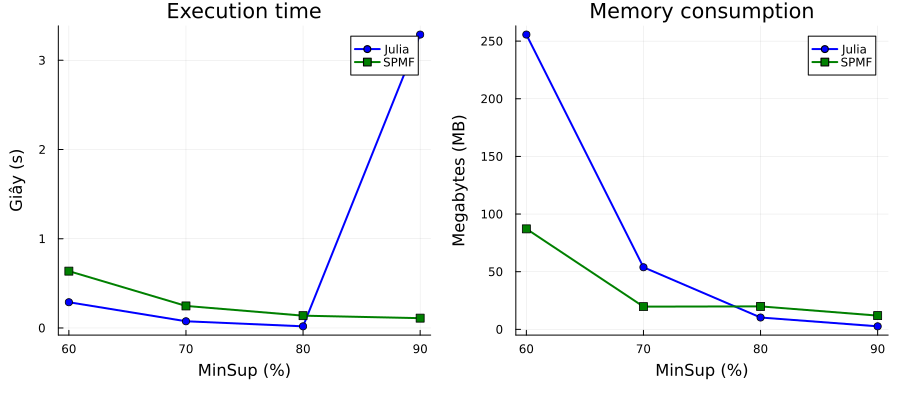

In [7]:
performance_result = eval_performance(CONFIG)
vis_performance(performance_result)


## Scalability Evaluation 

In [8]:
function eval_scalability(config)
    log_phase(logger, "SCALABILITY")
    transactions = FPGrowth.read_spmf(config["dataset"])
    total_txs = length(transactions)
    fixed_minsup = config["fixed_minsup_for_scalability"]
    log_info(logger, "Ngưỡng MinSup cố định=", fixed_minsup * 100, "%")
    
    results_df = DataFrame(DataRatio=Float64[], NumTransactions=Int[], JuliaTime=Float64[], SPMFTime=Float64[])
    
    @showprogress "Đang đo độ mở rộng... " for ratio in config["data_ratios"]
        num_tx = ceil(Int, total_txs * ratio)
        log_process(logger, "Data Ratio = ", ratio * 100, "% (", num_tx, " giao dịch) ...")
        
        sliced_txs = transactions[1:num_tx]
        temp_data_path = "../results/temp_chess_$(ratio).dat"
        open(temp_data_path, "w") do f
            for tx in sliced_txs
                println(f, join(tx, " "))
            end
        end
        
        min_sup_abs = ceil(Int, fixed_minsup * num_tx)
        
        # Julia
        time_before = time_ns()
        FPGrowth.fpgrowth(sliced_txs, min_sup_abs)
        time_after = time_ns()
        julia_time = (time_after - time_before) / 1e9
        
        # SPMF
        spmf_time, _ = exe_spmf(config, temp_data_path, config["output_spmf"], fixed_minsup)
        
        log_metric(logger, "Julia Time: ", round(julia_time, digits=3), "s | SPMF Time: ", round(spmf_time, digits=3), "s")
        push!(results_df, (ratio, num_tx, julia_time, spmf_time))
        
        rm(temp_data_path, force=true)
    end
    
    CSV.write(config["csv_scalability"], results_df)
    log_success(logger, "Saved at ", config["csv_scalability"])
    return results_df
end

function vis_scalability(df::DataFrame)
    log_phase(logger, "VIS SCALABILITY")
    x_vals = df.DataRatio .* 100
    
    p_scale = plot(x_vals, df.JuliaTime, label="Julia", marker=:circle, linewidth=2, color=:blue,
                   title="Scalability evaluation",
                   xlabel="Tỉ lệ dữ liệu (%)", ylabel="Thời gian thực thi (s)", legend=:topleft)
    plot!(p_scale, x_vals, df.SPMFTime, label="SPMF", marker=:square, linewidth=2, color=:green)
    
    display(plot(p_scale, bottom_margin=8mm, left_margin=5mm))
end


vis_scalability (generic function with 1 method)


__________________________________________________
[phase]  SCALABILITY
__________________________________________________
[info] Ngưỡng MinSup cố định=70.0%
[process] Data Ratio = 40.0% (1279 giao dịch) ...
   [metric] Julia Time: 2.162s | SPMF Time: 1.329s
[process] Data Ratio = 60.0% (1918 giao dịch) ...


Đang đo độ mở rộng...  50%|███████████████              |  ETA: 0:00:29

   [metric] Julia Time: 23.563s | SPMF Time: 0.455s
[process] Data Ratio = 80.0% (2557 giao dịch) ...


Đang đo độ mở rộng...  75%|██████████████████████       |  ETA: 0:00:10

   [metric] Julia Time: 0.112s | SPMF Time: 0.353s
[process] Data Ratio = 100.0% (3196 giao dịch) ...


Đang đo độ mở rộng... 100%|█████████████████████████████| Time: 0:00:30


   [metric] Julia Time: 0.085s | SPMF Time: 0.344s
[success] Saved at ../results/chess_metrics_scalability.csv

__________________________________________________
[phase]  VIS SCALABILITY
__________________________________________________


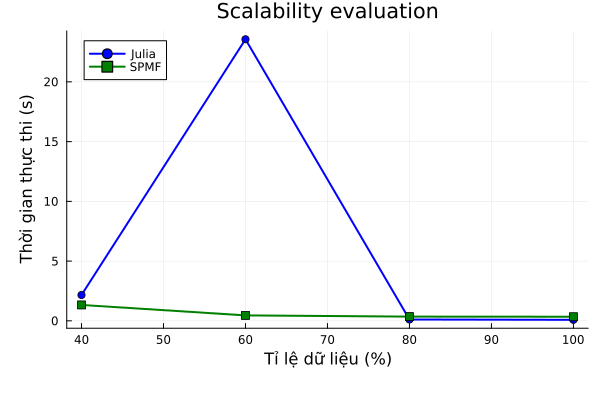

In [9]:
scalability_result = eval_scalability(CONFIG)
vis_scalability(scalability_result)
